In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision import datasets

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import time

In [ ]:
# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

BATCH_SIZE = 8

IMAGE_SIZE = 64

NUM_EPOCHS = 1000

LEARNING_RATE = 1e-4

SEED = 42


SAVE_DIR = "/content/drive/MyDrive/VKR additional experiments/ConvKAN"

os.makedirs(SAVE_DIR, exist_ok=True)

print("SAVE DIR:", SAVE_DIR)

model_name = 'ResNet50_FourierKAN'

checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_best.pth'
)


SAVE DIR: /content/drive/MyDrive/VKR additional experiments/ConvKAN


In [ ]:
# ============================================================
# SEED
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

# ============================================================
# TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# DATASET
# ============================================================

DATASET_PATH = (
    '/content/drive/MyDrive/caltech101/caltech101/101_ObjectCategories'
)

full_dataset = datasets.ImageFolder(

    root=DATASET_PATH,

    transform=train_transform
)

print('CLASSES:', len(full_dataset.classes))
print('IMAGES:', len(full_dataset))

# ============================================================
# SPLIT
# ============================================================

train_size = int(0.8 * len(full_dataset))

val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(

    full_dataset,

    [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

CLASSES: 101
IMAGES: 8677


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# ─────────────────────────────────────────────────────────────────────────────
# 1. KANLinear — линейный слой с B-сплайн активациями
# ─────────────────────────────────────────────────────────────────────────────

class KANLinear(nn.Module):
    """
    Один слой KAN: y_j = Σ_i φ_ij(x_i), где φ_ij — обучаемый B-сплайн.

    Параметры:
        in_features  : размер входа
        out_features : размер выхода
        grid_size    : число интервалов B-сплайна (больше → точнее, но больше параметров)
        spline_order : порядок B-сплайна (3 = кубический)
        scale_noise  : шум инициализации весов сплайна
        scale_base   : масштаб базовой линейной части (residual connection)
        grid_range   : диапазон входных значений для сетки сплайна
    """

    def __init__(
        self,
        in_features: int,
        out_features: int,
        grid_size: int = 5,
        spline_order: int = 3,
        scale_noise: float = 0.1,
        scale_base: float = 1.0,
        grid_range: tuple = (-1, 1),
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        # Равномерная сетка для B-сплайна, расширенная на spline_order с каждой стороны
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-spline_order, grid_size + spline_order + 1, dtype=torch.float32)
        grid = grid * h + grid_range[0]                        # (grid_size + 2*spline_order + 1,)
        self.register_buffer("grid", grid)

        # Веса: коэффициенты сплайна φ_ij для каждой пары (i, j)
        self.spline_weight = nn.Parameter(
            torch.empty(out_features, in_features, grid_size + spline_order)
        )
        # Базовая линейная часть (residual): обычный Linear без bias
        self.base_weight = nn.Parameter(
            torch.empty(out_features, in_features)
        )
        self.scale_base = scale_base

        self._reset_parameters(scale_noise)

    def _reset_parameters(self, scale_noise: float):
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
        nn.init.normal_(self.spline_weight, std=scale_noise)

    # ── B-сплайн базисные функции (рекурсия де Бура) ──────────────────────
    def b_splines(self, x: torch.Tensor) -> torch.Tensor:
        """
        Вычисляет B-сплайн базисные функции для входа x.

        Args:
            x : (batch, in_features)
        Returns:
            bases : (batch, in_features, grid_size + spline_order)
        """
        x = x.unsqueeze(-1)                                    # (B, in, 1)
        grid = self.grid                                        # (G,)

        # Порядок 0: ступенчатые функции
        bases = ((x >= grid[:-1]) & (x < grid[1:])).float()   # (B, in, G-1)

        # Рекурсивное повышение порядка
        for k in range(1, self.spline_order + 1):
            left  = (x - grid[:-(k + 1)]) / (grid[k:-1]     - grid[:-(k + 1)] + 1e-8)
            right = (grid[(k + 1):] - x)  / (grid[(k + 1):] - grid[1:-k]      + 1e-8)
            bases = left * bases[..., :-1] + right * bases[..., 1:]

        return bases.contiguous()                              # (B, in, grid_size+order)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (batch, in_features)  — значения нормированы в grid_range
        Returns:
            y : (batch, out_features)
        """
        # Базовая линейная часть
        base_out = F.linear(F.silu(x), self.base_weight * self.scale_base)

        # Сплайновая часть: φ_ij(x_i) = Σ_k  spline_weight[j,i,k] * B_k(x_i)
        spline_basis = self.b_splines(x)                       # (B, in, coeffs)
        # Сворачиваем: для каждого j суммируем по i и k
        spline_out = torch.einsum(
            "bik,jik->bj", spline_basis, self.spline_weight
        )

        return base_out + spline_out

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. ConvKAN — свёрточный слой на основе KANLinear
# ─────────────────────────────────────────────────────────────────────────────

class ConvKAN(nn.Module):
    """
    Свёрточный слой с KAN-преобразованием вместо обычного матричного умножения.

    Внутренне работает через im2col (unfold): каждый патч изображения
    превращается в вектор, к которому применяется KANLinear.

    Параметры совпадают с nn.Conv2d (groups не поддерживается для простоты).
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        stride: int = 1,
        padding: int = 0,
        grid_size: int = 5,
        spline_order: int = 3,
    ):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.stride       = stride
        self.padding      = padding

        in_dim = in_channels * kernel_size * kernel_size
        self.kan = KANLinear(
            in_features=in_dim,
            out_features=out_channels,
            grid_size=grid_size,
            spline_order=spline_order,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (B, C, H, W)
        Returns:
            out : (B, out_channels, H_out, W_out)
        """
        B, C, H, W = x.shape

        # im2col: разворачиваем патчи
        patches = F.unfold(
            x,
            kernel_size=self.kernel_size,
            stride=self.stride,
            padding=self.padding,
        )                                                      # (B, C*k*k, L)

        L = patches.shape[-1]
        patches = patches.permute(0, 2, 1).reshape(B * L, -1) # (B*L, C*k*k)

        # Нормируем вход в [-1, 1] для стабильности сплайна
        patches = torch.tanh(patches)

        out = self.kan(patches)                               # (B*L, out_channels)
        out = out.reshape(B, L, self.out_channels)
        out = out.permute(0, 2, 1)                            # (B, out_channels, L)

        H_out = (H + 2 * self.padding - self.kernel_size) // self.stride + 1
        W_out = (W + 2 * self.padding - self.kernel_size) // self.stride + 1
        out = out.reshape(B, self.out_channels, H_out, W_out)

        return out


# ─────────────────────────────────────────────────────────────────────────────
# 3. ConvKAN-сеть для классификации
# ─────────────────────────────────────────────────────────────────────────────

class ConvKANNet(nn.Module):
    """
    Простая сеть с двумя ConvKAN-слоями и классификатором.

    Схема (для MNIST 1×28×28):
        ConvKAN(1→16, k=3, p=1)  → BN → GELU → MaxPool → 16×14×14
        ConvKAN(16→32, k=3, p=1) → BN → GELU → MaxPool → 32×7×7
        Flatten → KANLinear(32*7*7 → 128) → GELU → Linear(128 → num_classes)
    """

    def __init__(
        self,
        in_channels: int = 1,
        num_classes: int = 10,
        grid_size: int = 5,
    ):
        super().__init__()

        self.block1 = nn.Sequential(
            ConvKAN(in_channels, 16, kernel_size=3, padding=1, grid_size=grid_size),
            nn.BatchNorm2d(16),
            nn.GELU(),
            nn.MaxPool2d(2),
        )
        self.block2 = nn.Sequential(
            ConvKAN(16, 32, kernel_size=3, padding=1, grid_size=grid_size),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(2),
        )

        # Адаптивный пулинг — работает с любым размером входа
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            KANLinear(32 * 4 * 4, 128, grid_size=grid_size),
            nn.GELU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x




In [ ]:
model_name = 'ConvKAN'

checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_best.pth'
)

model = ConvKANNet(

    in_channels=3,

    num_classes=len(full_dataset.classes),

    grid_size=3

).to(DEVICE)

In [ ]:
# ============================================================
# LOSS / OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20
)

# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=10,

        min_delta=0.0
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f'EarlyStopping: {self.counter}/{self.patience}'
            )

            if self.counter >= self.patience:

                self.stop = True

early_stopping = EarlyStopping(

    patience=10,

    min_delta=1e-4
)

# ============================================================
# EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    losses = []

    preds_all = []

    targets_all = []

    for images, targets in loader:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        preds_all.extend(
            preds.cpu().numpy()
        )

        targets_all.extend(
            targets.cpu().numpy()
        )

    metrics = {

        'loss': np.mean(losses),

        'accuracy': accuracy_score(
            targets_all,
            preds_all
        ),

        'precision': precision_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'recall': recall_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'f1': f1_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        )
    }

    return metrics

# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler('cuda', enabled=False)

In [ ]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Всего параметров:     {total_params:,}')
print(f'Обучаемых параметров: {trainable_params:,}')

# ============================================================
# LOSS / OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20
)

# ============================================================
# TRAINING
# ============================================================

history     = []
best_acc    = 0.0
start_epoch = 0

# ============================================================
# RESUME CHECKPOINT
# ============================================================

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(

        checkpoint_path,

        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    scheduler.load_state_dict(
        checkpoint['scheduler_state_dict']
    )

    best_acc    = checkpoint['best_acc']
    history     = checkpoint['history']
    start_epoch = checkpoint['epoch'] + 1

    early_stopping.counter   = checkpoint.get('early_stopping_counter', 0)
    early_stopping.best_loss = checkpoint.get('early_stopping_best_loss', np.inf)

    print('CHECKPOINT LOADED')
    print(f'START EPOCH: {start_epoch}')
    print(f'BEST ACC:    {best_acc:.4f}')

# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(

    'cuda',

    enabled=torch.cuda.is_available()
)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()

    train_losses  = []
    train_preds   = []
    train_targets = []

    loop = tqdm(train_loader)

    for images, targets in loop:

        images  = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        # ====================================================
        # MIXED PRECISION
        # ====================================================

        with torch.amp.autocast(

            device_type='cuda',

            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        # ====================================================
        # BACKPROP
        # ====================================================

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        # ====================================================
        # TRAIN METRICS
        # ====================================================

        train_losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.detach().cpu().numpy()
        )

        train_targets.extend(
            targets.detach().cpu().numpy()
        )

        loop.set_description(
            f'Epoch {epoch+1}'
        )

        loop.set_postfix(
            loss=loss.item()
        )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()

    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = np.mean(train_losses)

    train_acc = accuracy_score(

        train_targets,

        train_preds
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_metrics = evaluate(

        model,

        val_loader,

        criterion
    )

    # ========================================================
    # RESULTS
    # ========================================================

    result = {

        'epoch':      epoch + 1,

        'train_loss': float(train_loss),
        'val_loss':   float(val_metrics['loss']),

        'train_acc':  float(train_acc),
        'val_acc':    float(val_metrics['accuracy']),

        'precision':  float(val_metrics['precision']),
        'recall':     float(val_metrics['recall']),
        'f1':         float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # ========================================================
    # CHECKPOINT STATE
    # ========================================================

    ckpt = {

        'epoch':                epoch,

        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),

        'best_acc': best_acc,
        'history':  history,

        'early_stopping_counter':   early_stopping.counter,
        'early_stopping_best_loss': early_stopping.best_loss
    }

    # ========================================================
    # SAVE LAST CHECKPOINT
    # ========================================================

    torch.save(

        ckpt,

        os.path.join(
            SAVE_DIR,
            f'{model_name}_last.pth'
        )
    )

    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    if val_metrics['accuracy'] > best_acc:

        best_acc         = val_metrics['accuracy']
        ckpt['best_acc'] = best_acc

        torch.save(ckpt, checkpoint_path)

        print(
            f'BEST CHECKPOINT SAVED: '
            f'{best_acc:.4f}'
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(
        val_metrics['loss']
    )

    if early_stopping.stop:

        print('EARLY STOPPING')

        break

# ============================================================
# SAVE HISTORY CSV
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(

    os.path.join(
        SAVE_DIR,
        f'{model_name}_history.csv'
    ),

    index=False
)

print('TRAINING FINISHED')
print(f'BEST VAL ACC: {best_acc:.4f}')

Всего параметров:     507,157
Обучаемых параметров: 507,157


Epoch 1: 100%|██████████| 868/868 [54:04<00:00,  3.74s/it, loss=2.94]


{'epoch': 1, 'train_loss': 3.8084888425290857, 'val_loss': 3.3856334071005545, 'train_acc': 0.2237429765163521, 'val_acc': 0.2966589861751152, 'precision': 0.07291313259318122, 'recall': 0.0657297268672624, 'f1': 0.05051309563384254}
BEST CHECKPOINT SAVED: 0.2967


Epoch 2: 100%|██████████| 868/868 [16:28<00:00,  1.14s/it, loss=3.6]


{'epoch': 2, 'train_loss': 3.1375081182075535, 'val_loss': 2.9838510334217054, 'train_acc': 0.3369831436392451, 'val_acc': 0.3692396313364055, 'precision': 0.1384122758537029, 'recall': 0.1397090696151462, 'f1': 0.1153986352561318}
BEST CHECKPOINT SAVED: 0.3692


...

Epoch 18: 100%|██████████| 868/868 [15:53<00:00,  1.10s/it, loss=1.59]


{'epoch': 18, 'train_loss': 1.505698919897118, 'val_loss': 1.9218722805380821, 'train_acc': 0.6526437112807952, 'val_acc': 0.5622119815668203, 'precision': 0.4034597069351823, 'recall': 0.37344044464898474, 'f1': 0.3629687839578445}
BEST CHECKPOINT SAVED: 0.5622


Epoch 19: 100%|██████████| 868/868 [15:56<00:00,  1.10s/it, loss=1.29]


{'epoch': 19, 'train_loss': 1.4939246308144336, 'val_loss': 1.910012297847304, 'train_acc': 0.6562454977668923, 'val_acc': 0.565668202764977, 'precision': 0.3883333993462047, 'recall': 0.3779912933369964, 'f1': 0.3616433212718689}
BEST CHECKPOINT SAVED: 0.5657


Epoch 20:   3%|▎         | 28/868 [00:31<16:28,  1.18s/it, loss=2.23]

In [ ]:

checkpoint_path = os.path.join(
    SAVE_DIR,
    'ConvKAN_best.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 19
BEST ACC: 0.5657


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

Epoch 20: 100%|██████████| 868/868 [1:17:00<00:00,  5.32s/it, loss=0.633]


{'epoch': 20, 'train_loss': 1.421087852812239, 'val_loss': 1.916942906029488, 'train_acc': 0.6706526437112807, 'val_acc': 0.5650921658986175, 'precision': 0.3895774714043644, 'recall': 0.373020021038528, 'f1': 0.36011922567079263}


Epoch 21: 100%|██████████| 868/868 [18:13<00:00,  1.26s/it, loss=1.59]


{'epoch': 21, 'train_loss': 1.4221345770262903, 'val_loss': 1.9096266492720573, 'train_acc': 0.6746866445757096, 'val_acc': 0.5650921658986175, 'precision': 0.3868094149817052, 'recall': 0.3779395379719942, 'f1': 0.3615508386122549}


Epoch 22: 100%|██████████| 868/868 [19:04<00:00,  1.32s/it, loss=1.55]


...

Epoch 33: 100%|██████████| 868/868 [20:37<00:00,  1.43s/it, loss=1.47]


{'epoch': 33, 'train_loss': 1.198404357502503, 'val_loss': 1.8027053789368697, 'train_acc': 0.7184843682466503, 'val_acc': 0.5869815668202765, 'precision': 0.4320821020282279, 'recall': 0.4097575743041247, 'f1': 0.39578097768951553}


Epoch 34: 100%|██████████| 868/868 [20:21<00:00,  1.41s/it, loss=0.888]


{'epoch': 34, 'train_loss': 1.1554449026490035, 'val_loss': 1.794612558635836, 'train_acc': 0.7297219420832733, 'val_acc': 0.591589861751152, 'precision': 0.45084618951411637, 'recall': 0.42811847757764304, 'f1': 0.40609609726256624}
CHECKPOINT SAVED: 0.5916


Epoch 35: 100%|██████████| 868/868 [20:15<00:00,  1.40s/it, loss=2.98]


In [ ]:

checkpoint_path = os.path.join(
    SAVE_DIR,
    'ConvKAN_best.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 34
BEST ACC: 0.5916


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

Epoch 35: 100%|██████████| 868/868 [46:10<00:00,  3.19s/it, loss=0.432]


{'epoch': 35, 'train_loss': 1.1167693007351136, 'val_loss': 1.7806864056890737, 'train_acc': 0.7351966575421409, 'val_acc': 0.6025345622119815, 'precision': 0.49486518224106607, 'recall': 0.43106706787130217, 'f1': 0.42314372750359974}
CHECKPOINT SAVED: 0.6025


Epoch 36: 100%|██████████| 868/868 [07:30<00:00,  1.93it/s, loss=1.23]


{'epoch': 36, 'train_loss': 1.059222896347329, 'val_loss': 1.740156448519175, 'train_acc': 0.74629015991932, 'val_acc': 0.6059907834101382, 'precision': 0.46089817494867746, 'recall': 0.42988939338021004, 'f1': 0.4158410691887287}
CHECKPOINT SAVED: 0.6060


Epoch 37: 100%|██████████| 868/868 [07:25<00:00,  1.95it/s, loss=1.24]


{'epoch': 37, 'train_loss': 1.0112778460649852, 'val_loss': 1.718952376549969, 'train_acc': 0.766172021322576, 'val_acc': 0.6082949308755761, 'precision': 0.4778601522692951, 'recall': 0.4330209413521925, 'f1': 0.4298069599571967}
CHECKPOINT SAVED: 0.6083


Epoch 38: 100%|██████████| 868/868 [07:26<00:00,  1.95it/s, loss=1.37]


In [ ]:

checkpoint_path = os.path.join(
    SAVE_DIR,
    'ConvKAN_best.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 37
BEST ACC: 0.6083


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

Epoch 38: 100%|██████████| 868/868 [1:39:02<00:00,  6.85s/it, loss=0.323]


{'epoch': 38, 'train_loss': 0.9731548926685744, 'val_loss': 1.7268844653727822, 'train_acc': 0.7687653075925659, 'val_acc': 0.6123271889400922, 'precision': 0.5079996662405943, 'recall': 0.4438075700440956, 'f1': 0.43716663817463375}
CHECKPOINT SAVED: 0.6123


Epoch 39: 100%|██████████| 868/868 [17:13<00:00,  1.19s/it, loss=1.03]


{'epoch': 39, 'train_loss': 0.9117131722739078, 'val_loss': 1.6853887590189134, 'train_acc': 0.7853335254286126, 'val_acc': 0.6175115207373272, 'precision': 0.49073965895185606, 'recall': 0.4444485615386354, 'f1': 0.4317148564900393}
CHECKPOINT SAVED: 0.6175


Epoch 40: 100%|██████████| 868/868 [17:13<00:00,  1.19s/it, loss=1.08]


...

{'epoch': 41, 'train_loss': 0.8190302498260951, 'val_loss': 1.6656004584948039, 'train_acc': 0.8121308168851751, 'val_acc': 0.6226958525345622, 'precision': 0.4914240599474612, 'recall': 0.44792808055829963, 'f1': 0.4439708391556282}
CHECKPOINT SAVED: 0.6227


Epoch 42: 100%|██████████| 868/868 [17:17<00:00,  1.19s/it, loss=1.02]


{'epoch': 42, 'train_loss': 0.7685889189017825, 'val_loss': 1.6566973362924866, 'train_acc': 0.8196225327762571, 'val_acc': 0.6180875576036866, 'precision': 0.4879056418131132, 'recall': 0.45448059017107467, 'f1': 0.440455020855811}


Epoch 43:  19%|█▉        | 163/868 [03:19<14:21,  1.22s/it, loss=0.437]


KeyboardInterrupt: 

In [ ]:

checkpoint_path = os.path.join(
    SAVE_DIR,
    'ConvKAN_best.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 41
BEST ACC: 0.6227


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

Epoch 42: 100%|██████████| 868/868 [17:44<00:00,  1.23s/it, loss=0.394]


{'epoch': 42, 'train_loss': 0.7659349577299701, 'val_loss': 1.6541348729917806, 'train_acc': 0.8219276761273592, 'val_acc': 0.6232718894009217, 'precision': 0.5041212318714787, 'recall': 0.4662784272825677, 'f1': 0.45329901802840417}
CHECKPOINT SAVED: 0.6233


Epoch 43: 100%|██████████| 868/868 [17:29<00:00,  1.21s/it, loss=0.392]


{'epoch': 43, 'train_loss': 0.7175173426373145, 'val_loss': 1.6293433073581913, 'train_acc': 0.8348941074773087, 'val_acc': 0.6244239631336406, 'precision': 0.49918419200472636, 'recall': 0.45990380451914437, 'f1': 0.4534456605882916}
CHECKPOINT SAVED: 0.6244


Epoch 44: 100%|██████████| 868/868 [17:34<00:00,  1.21s/it, loss=0.976]


...

Epoch 47: 100%|██████████| 868/868 [17:33<00:00,  1.21s/it, loss=0.407]


{'epoch': 47, 'train_loss': 0.5719079122736982, 'val_loss': 1.6012674119872843, 'train_acc': 0.8760985448782597, 'val_acc': 0.6330645161290323, 'precision': 0.4963579431361461, 'recall': 0.48191694472492685, 'f1': 0.46511550845346034}
CHECKPOINT SAVED: 0.6331


Epoch 48: 100%|██████████| 868/868 [17:43<00:00,  1.22s/it, loss=2.1]


{'epoch': 48, 'train_loss': 0.5447488631495202, 'val_loss': 1.576725492537159, 'train_acc': 0.884310618066561, 'val_acc': 0.6440092165898618, 'precision': 0.495980605623611, 'recall': 0.4933372954433093, 'f1': 0.4753887362083892}
CHECKPOINT SAVED: 0.6440


Epoch 49:  76%|███████▋  | 662/868 [13:25<03:41,  1.07s/it, loss=0.344]

In [ ]:

checkpoint_path = os.path.join(
    SAVE_DIR,
    'ConvKAN_best.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 48
BEST ACC: 0.6440


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

Epoch 49: 100%|██████████| 868/868 [1:01:59<00:00,  4.29s/it, loss=0.178]


{'epoch': 49, 'train_loss': 0.5178788655559846, 'val_loss': 1.600134065756703, 'train_acc': 0.8899294049848725, 'val_acc': 0.6394009216589862, 'precision': 0.5173820926972049, 'recall': 0.4817180200428411, 'f1': 0.47364351784935527}


Epoch 50: 100%|██████████| 868/868 [18:42<00:00,  1.29s/it, loss=0.547]


{'epoch': 50, 'train_loss': 0.48364721531636395, 'val_loss': 1.5629228373757704, 'train_acc': 0.8974211208759545, 'val_acc': 0.646889400921659, 'precision': 0.5117928210111131, 'recall': 0.49398087395617885, 'f1': 0.483144155299793}
CHECKPOINT SAVED: 0.6469


Epoch 51: 100%|██████████| 868/868 [19:25<00:00,  1.34s/it, loss=0.618]


...

Epoch 58: 100%|██████████| 868/868 [19:04<00:00,  1.32s/it, loss=1.26]


{'epoch': 58, 'train_loss': 0.3941334256685601, 'val_loss': 1.5381226096353773, 'train_acc': 0.9270998415213946, 'val_acc': 0.6526497695852534, 'precision': 0.5076791865364784, 'recall': 0.5055734742797965, 'f1': 0.4935004956213778}
CHECKPOINT SAVED: 0.6526


Epoch 59: 100%|██████████| 868/868 [19:04<00:00,  1.32s/it, loss=0.258]


{'epoch': 59, 'train_loss': 0.3919984951871769, 'val_loss': 1.5387657204050622, 'train_acc': 0.9283964846563896, 'val_acc': 0.6543778801843319, 'precision': 0.5248370098152795, 'recall': 0.5100280476906219, 'f1': 0.49937766173061476}
CHECKPOINT SAVED: 0.6544


Epoch 60:  51%|█████     | 441/868 [09:04<08:29,  1.19s/it, loss=0.375]

In [ ]:

checkpoint_path = os.path.join(
    SAVE_DIR,
    'ConvKAN_best.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 59
BEST ACC: 0.6544


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

Epoch 60: 100%|██████████| 868/868 [1:29:13<00:00,  6.17s/it, loss=0.0905]


{'epoch': 60, 'train_loss': 0.3929706954392969, 'val_loss': 1.5512649841297608, 'train_acc': 0.9276761273591702, 'val_acc': 0.6480414746543779, 'precision': 0.5044696682132687, 'recall': 0.5016185899028675, 'f1': 0.48982343853034244}


Epoch 61: 100%|██████████| 868/868 [01:01<00:00, 14.13it/s, loss=0.373]


{'epoch': 61, 'train_loss': 0.3912333390302098, 'val_loss': 1.5356825166446273, 'train_acc': 0.9295490563319406, 'val_acc': 0.6497695852534562, 'precision': 0.5083588943911675, 'recall': 0.5034552020222651, 'f1': 0.48894459478522}


Epoch 62: 100%|██████████| 868/868 [01:01<00:00, 14.15it/s, loss=0.407]


...

Epoch 147: 100%|██████████| 868/868 [01:02<00:00, 13.97it/s, loss=0.00537]


{'epoch': 147, 'train_loss': 0.004614522246295728, 'val_loss': 1.9341981182312635, 'train_acc': 0.9994237141622244, 'val_acc': 0.6710829493087558, 'precision': 0.5489331346301473, 'recall': 0.5339007600422663, 'f1': 0.5252257910080937}


Epoch 148: 100%|██████████| 868/868 [01:02<00:00, 13.94it/s, loss=0.00147]


{'epoch': 148, 'train_loss': 0.004354199179993247, 'val_loss': 1.9283313985381807, 'train_acc': 0.9997118570811122, 'val_acc': 0.673963133640553, 'precision': 0.5494325432379032, 'recall': 0.5350299557520093, 'f1': 0.5273588234844278}


Epoch 149: 100%|██████████| 868/868 [01:01<00:00, 14.07it/s, loss=0.122]


In [ ]:

checkpoint_path = os.path.join(
    SAVE_DIR,
    'ConvKAN_best.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 143
BEST ACC: 0.6757


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

Epoch 144: 100%|██████████| 868/868 [52:37<00:00,  3.64s/it, loss=0.00851]


{'epoch': 144, 'train_loss': 0.0044087445665287545, 'val_loss': 1.9274028996692343, 'train_acc': 0.9995677856216684, 'val_acc': 0.6676267281105991, 'precision': 0.5508267319573854, 'recall': 0.52585409325271, 'f1': 0.5194802660794642}


Epoch 145: 100%|██████████| 868/868 [16:36<00:00,  1.15s/it, loss=0.00162]


{'epoch': 145, 'train_loss': 0.004476690514087339, 'val_loss': 1.9130602924156963, 'train_acc': 0.9994237141622244, 'val_acc': 0.6676267281105991, 'precision': 0.5471944771515648, 'recall': 0.5266737364563722, 'f1': 0.5201595199832876}


Epoch 146:  32%|███▏      | 279/868 [05:16<10:21,  1.05s/it, loss=0.00182]

BEST ACC:    0.6757
EPOCHS RUN:  143
     epoch  train_loss  val_loss  train_acc   val_acc  precision    recall  \
138    139    0.004372  1.910532   0.999712  0.675115   0.549529  0.533756   
139    140    0.004731  1.914150   0.999712  0.668203   0.537811  0.526549   
140    141    0.004535  1.895553   0.999712  0.668203   0.540989  0.526119   
141    142    0.004384  1.916644   0.999568  0.671083   0.537748  0.529234   
142    143    0.004592  1.893679   0.999568  0.675691   0.548184  0.535998   

           f1  
138  0.524045  
139  0.516547  
140  0.518143  
141  0.518489  
142  0.529031  


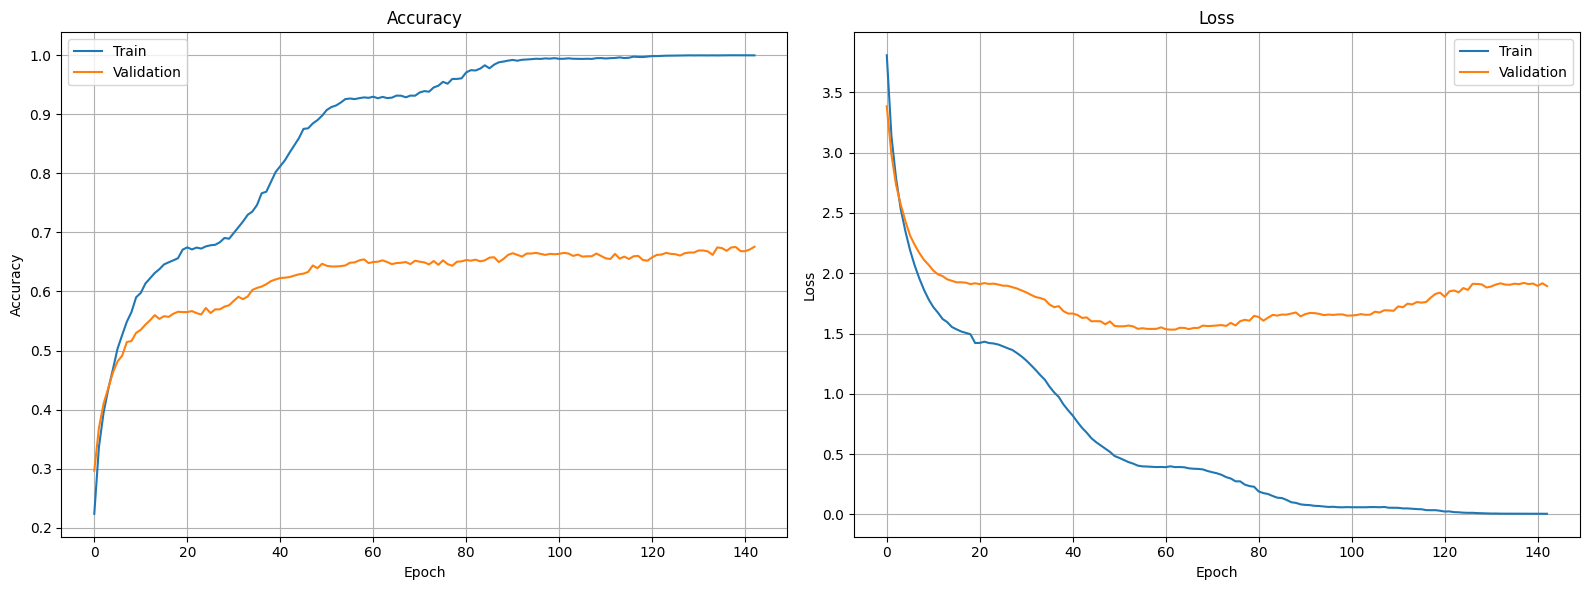

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ============================================================
# LOAD CHECKPOINT
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/VKR additional experiments/ConvKAN"

checkpoint_path = os.path.join(SAVE_DIR, 'ConvKAN_best.pth')

checkpoint = torch.load(
    checkpoint_path,
    map_location='cpu',
    weights_only=False
)

history = checkpoint['history']
best_acc = checkpoint['best_acc']

print(f'BEST ACC:    {best_acc:.4f}')
print(f'EPOCHS RUN:  {len(history)}')

# ============================================================
# HISTORY → DATAFRAME
# ============================================================

history_df = pd.DataFrame(history)

print(history_df.tail())

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(history_df['train_acc'], label='Train')
axes[0].plot(history_df['val_acc'],   label='Validation')

axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_df['train_loss'], label='Train')
axes[1].plot(history_df['val_loss'],   label='Validation')

axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ConvKAN_history.png'), dpi=150)
plt.show()

In [ ]:
# ============================================================
# Baseline CNN для сравнения с ConvKAN
# Архитектура максимально близка к ConvKANNet:
# ConvKAN заменён на nn.Conv2d
# KANLinear заменён на nn.Linear
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset

from torchvision import transforms
from torchvision import datasets

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

BATCH_SIZE = 8

IMAGE_SIZE = 64

NUM_EPOCHS = 1000

LEARNING_RATE = 1e-4

SEED = 42

SAVE_DIR = "/content/drive/MyDrive/VKR additional experiments/CNN_baseline"

os.makedirs(SAVE_DIR, exist_ok=True)

print("SAVE DIR:", SAVE_DIR)

model_name = "CNN_baseline"

checkpoint_path = os.path.join(
    SAVE_DIR,
    f"{model_name}_best.pth"
)


# ============================================================
# SEED
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)


# ============================================================
# TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# DATASET
# ============================================================

DATASET_PATH = (
    "/content/drive/MyDrive/caltech101/caltech101/101_ObjectCategories"
)

# Важно:
# создаём ДВА ImageFolder, чтобы train_transform и val_transform
# не перетирали друг друга после random_split / Subset.

train_full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=train_transform
)

val_full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=val_transform
)

num_classes = len(train_full_dataset.classes)

print("CLASSES:", num_classes)
print("IMAGES:", len(train_full_dataset))


# ============================================================
# SPLIT 80/20
# ============================================================

indices = list(range(len(train_full_dataset)))

random.shuffle(indices)

train_size = int(0.8 * len(indices))

train_indices = indices[:train_size]

val_indices = indices[train_size:]

train_dataset = Subset(
    train_full_dataset,
    train_indices
)

val_dataset = Subset(
    val_full_dataset,
    val_indices
)

print("TRAIN IMAGES:", len(train_dataset))
print("VAL IMAGES:", len(val_dataset))


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


# ============================================================
# CNN, аналогичная ConvKANNet
# ============================================================

class CNNBaselineNet(nn.Module):
    """
    CNN для честного сравнения с ConvKANNet.

    Схема:
        Conv2d(3→16, k=3, p=1)  → BN → GELU → MaxPool
        Conv2d(16→32, k=3, p=1) → BN → GELU → MaxPool
        AdaptiveAvgPool2d((4, 4))
        Flatten
        Linear(32*4*4 → 128)
        GELU
        Linear(128 → num_classes)

    Отличие от ConvKANNet:
        ConvKAN заменён на обычный Conv2d,
        KANLinear заменён на обычный Linear.
    """

    def __init__(
        self,
        in_channels: int = 3,
        num_classes: int = 101
    ):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=16,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.GELU(),
            nn.MaxPool2d(2),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Linear(32 * 4 * 4, 128),
            nn.GELU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x


model = CNNBaselineNet(

    in_channels=3,

    num_classes=num_classes

).to(DEVICE)


# ============================================================
# PARAMS
# ============================================================

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Всего параметров:     {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")


# ============================================================
# LOSS / OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20
)


# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(
        self,
        patience=10,
        min_delta=0.0
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f"EarlyStopping: {self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.stop = True


early_stopping = EarlyStopping(

    patience=10,

    min_delta=1e-4
)


# ============================================================
# EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    losses = []

    preds_all = []

    targets_all = []

    for images, targets in loader:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        preds_all.extend(
            preds.cpu().numpy()
        )

        targets_all.extend(
            targets.cpu().numpy()
        )

    metrics = {

        "loss": np.mean(losses),

        "accuracy": accuracy_score(
            targets_all,
            preds_all
        ),

        "precision": precision_score(
            targets_all,
            preds_all,
            average="macro",
            zero_division=0
        ),

        "recall": recall_score(
            targets_all,
            preds_all,
            average="macro",
            zero_division=0
        ),

        "f1": f1_score(
            targets_all,
            preds_all,
            average="macro",
            zero_division=0
        ),

        "targets": targets_all,

        "preds": preds_all
    }

    return metrics


# ============================================================
# TRAINING STATE
# ============================================================

history = []

best_acc = 0.0

start_epoch = 0


# ============================================================
# RESUME CHECKPOINT
# ============================================================

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(

        checkpoint_path,

        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    scheduler.load_state_dict(
        checkpoint["scheduler_state_dict"]
    )

    best_acc = checkpoint["best_acc"]

    history = checkpoint["history"]

    start_epoch = checkpoint["epoch"] + 1

    early_stopping.counter = checkpoint.get(
        "early_stopping_counter",
        0
    )

    early_stopping.best_loss = checkpoint.get(
        "early_stopping_best_loss",
        np.inf
    )

    print("CHECKPOINT LOADED")

    print(f"START EPOCH: {start_epoch}")

    print(f"BEST ACC:    {best_acc:.4f}")


# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(

    "cuda",

    enabled=torch.cuda.is_available()
)


# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()

    train_losses = []

    train_preds = []

    train_targets = []

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        # ====================================================
        # MIXED PRECISION
        # ====================================================

        with torch.amp.autocast(

            device_type="cuda",

            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        # ====================================================
        # BACKPROP
        # ====================================================

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        # ====================================================
        # TRAIN METRICS
        # ====================================================

        train_losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.detach().cpu().numpy()
        )

        train_targets.extend(
            targets.detach().cpu().numpy()
        )

        loop.set_description(
            f"Epoch {epoch + 1}"
        )

        loop.set_postfix(
            loss=loss.item()
        )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()

    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = np.mean(train_losses)

    train_acc = accuracy_score(

        train_targets,

        train_preds
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_metrics = evaluate(

        model,

        val_loader,

        criterion
    )

    # ========================================================
    # RESULTS
    # ========================================================

    result = {

        "epoch": epoch + 1,

        "train_loss": float(train_loss),

        "val_loss": float(val_metrics["loss"]),

        "train_acc": float(train_acc),

        "val_acc": float(val_metrics["accuracy"]),

        "precision": float(val_metrics["precision"]),

        "recall": float(val_metrics["recall"]),

        "f1": float(val_metrics["f1"])
    }

    history.append(result)

    print(result)

    # ========================================================
    # CHECKPOINT STATE
    # ========================================================

    ckpt = {

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "scheduler_state_dict": scheduler.state_dict(),

        "best_acc": best_acc,

        "history": history,

        "early_stopping_counter": early_stopping.counter,

        "early_stopping_best_loss": early_stopping.best_loss
    }

    # ========================================================
    # SAVE LAST CHECKPOINT
    # ========================================================

    torch.save(

        ckpt,

        os.path.join(
            SAVE_DIR,
            f"{model_name}_last.pth"
        )
    )

    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    if val_metrics["accuracy"] > best_acc:

        best_acc = val_metrics["accuracy"]

        ckpt["best_acc"] = best_acc

        torch.save(
            ckpt,
            checkpoint_path
        )

        print(
            f"BEST CHECKPOINT SAVED: "
            f"{best_acc:.4f}"
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(
        val_metrics["loss"]
    )

    if early_stopping.stop:

        print("EARLY STOPPING")

        break


# ============================================================
# SAVE HISTORY CSV
# ============================================================

history_df = pd.DataFrame(history)

history_csv_path = os.path.join(
    SAVE_DIR,
    f"{model_name}_history.csv"
)

history_df.to_csv(
    history_csv_path,
    index=False
)

print("TRAINING FINISHED")
print(f"BEST VAL ACC: {best_acc:.4f}")
print("HISTORY SAVED:", history_csv_path)


# ============================================================
# LOAD BEST MODEL AND FINAL REPORT
# ============================================================

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

final_metrics = evaluate(
    model,
    val_loader,
    criterion
)

print("\nFINAL CNN BASELINE RESULTS")
print(f"BEST EPOCH: {checkpoint['epoch'] + 1}")
print(f"VAL LOSS:  {final_metrics['loss']:.4f}")
print(f"VAL ACC:   {final_metrics['accuracy']:.4f}")
print(f"PRECISION: {final_metrics['precision']:.4f}")
print(f"RECALL:    {final_metrics['recall']:.4f}")
print(f"F1:        {final_metrics['f1']:.4f}")


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    final_metrics["targets"],
    final_metrics["preds"],
    target_names=train_full_dataset.classes,
    digits=4,
    zero_division=0
)

print(report)

report_path = os.path.join(
    SAVE_DIR,
    f"{model_name}_classification_report.txt"
)

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("REPORT SAVED:", report_path)


# ============================================================
# SUMMARY CSV FOR PRESENTATION
# ============================================================

summary = pd.DataFrame([{

    "model": model_name,

    "dataset": "Caltech-101",

    "image_size": IMAGE_SIZE,

    "batch_size": BATCH_SIZE,

    "best_epoch": checkpoint["epoch"] + 1,

    "accuracy": final_metrics["accuracy"],

    "precision_macro": final_metrics["precision"],

    "recall_macro": final_metrics["recall"],

    "f1_macro": final_metrics["f1"],

    "total_params": total_params,

    "trainable_params": trainable_params
}])

summary_path = os.path.join(
    SAVE_DIR,
    f"{model_name}_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

print("\nSUMMARY:")
print(summary)

print("SUMMARY SAVED:", summary_path)

SAVE DIR: /content/drive/MyDrive/VKR additional experiments/CNN_baseline
CLASSES: 101
IMAGES: 8677
TRAIN IMAGES: 6941
VAL IMAGES: 1736
Всего параметров:     83,877
Обучаемых параметров: 83,877


Epoch 1: 100%|██████████| 868/868 [45:32<00:00,  3.15s/it, loss=4.13]


{'epoch': 1, 'train_loss': 3.951182463202059, 'val_loss': 3.551613029796407, 'train_acc': 0.18801325457426885, 'val_acc': 0.25057603686635943, 'precision': 0.03362854010546473, 'recall': 0.040134580047865596, 'f1': 0.025167169264844656}
BEST CHECKPOINT SAVED: 0.2506


Epoch 2: 100%|██████████| 868/868 [00:41<00:00, 20.90it/s, loss=2.73]


{'epoch': 2, 'train_loss': 3.4037234346438114, 'val_loss': 3.180981719548801, 'train_acc': 0.2803630600777986, 'val_acc': 0.31682027649769584, 'precision': 0.06478551925057935, 'recall': 0.07360024475141308, 'f1': 0.057075543081911304}
BEST CHECKPOINT SAVED: 0.3168


...

Epoch 35: 100%|██████████| 868/868 [00:42<00:00, 20.48it/s, loss=1.66]


{'epoch': 35, 'train_loss': 1.9057245617088634, 'val_loss': 1.9300646054030564, 'train_acc': 0.552225904048408, 'val_acc': 0.5420506912442397, 'precision': 0.3573680031965376, 'recall': 0.32919685971728024, 'f1': 0.3085541894718846}
BEST CHECKPOINT SAVED: 0.5421


Epoch 36: 100%|██████████| 868/868 [00:43<00:00, 19.78it/s, loss=0.987]


{'epoch': 36, 'train_loss': 1.866184349673959, 'val_loss': 1.9219506220883489, 'train_acc': 0.5555395476156173, 'val_acc': 0.5483870967741935, 'precision': 0.33473685133744435, 'recall': 0.3309531017640555, 'f1': 0.30619572059727135}
BEST CHECKPOINT SAVED: 0.5484


Epoch 37: 100%|██████████| 868/868 [00:43<00:00, 19.81it/s, loss=2.17]
